# And

Bloqs for doing "AND" logical operations.

The behavior is modified by the 'control variable' attributes. A traditional value of '1'
means that a bit value of '1' is logical true for the and operation. A control value of
'0' means that a bit value of '0' is the logical true.

The `Toffoli` bloq is similar to the `And` bloq. Toffoli will flip the target bit according
to the and of its control registers. `And` will output the result into a fresh register.

In [1]:
from qualtran import Bloq, CompositeBloq, BloqBuilder, Signature, Register
from qualtran import QBit, QInt, QUInt, QAny
from qualtran.drawing import show_bloq, show_call_graph, show_counts_sigma
from typing import *
import numpy as np
import sympy
import cirq

## `And`
A two-bit 'and' operation optimized for T-count.

#### Parameters
 - `cv1`: Whether the first bit is a positive control.
 - `cv2`: Whether the second bit is a positive control. 

#### Registers
 - `ctrl`: A two-bit control register.
 - `target [right]`: The output bit. 

#### References
 - [Encoding Electronic Spectra in Quantum Circuits with Linear T Complexity](https://arxiv.org/abs/1805.03662).     Babbush et al. 2018. Section III.A. and Fig. 4.
 - [Verifying Measurement Based Uncomputation](https://algassert.com/post/1903). Gidney, C. 2019.


In [2]:
from qualtran.bloqs.mcmt import And

### Example Instances

In [3]:
and_bloq = And()

#### Graphical Signature

In [4]:
from qualtran.drawing import show_bloqs
show_bloqs([and_bloq],
           ['`and_bloq`'])

### Call Graph

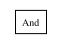

#### Counts totals:
 - `And`: 1

In [5]:
from qualtran.resource_counting.generalizers import ignore_split_join
and_bloq_g, and_bloq_sigma = and_bloq.call_graph(max_depth=1, generalizer=ignore_split_join)
show_call_graph(and_bloq_g)
show_counts_sigma(and_bloq_sigma)

### Clifford + T implementation

`And` will be considered an Atomic (non-decomposable) bloq within the Qualtran standard library. An additional method is provided to assist in fully compiling to a Clifford+T gateset.

In [6]:
and_bloq.to_clifford_t_circuit()

ctrl_0: ───────────@───────X───T^-1──────────X───────────────
                   │       │                 │
ctrl_1: ───────────┼───@───┼───X──────T^-1───┼───X───────────
                   │   │   │   │             │   │
target: ───H───T───X───X───@───@──────T──────@───@───H───S───

In [7]:
and_bloq.adjoint().to_clifford_t_circuit()

┌──┐
ctrl_0: ────────────@─────
                    ║
ctrl_1: ────────────@─────
                    ║
target: ───H───M────╫R────
               ║    ║
target: ═══════@════^═════
                   └──┘

## MBUC

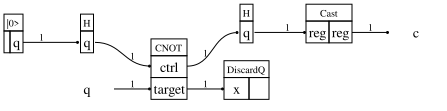

In [8]:
from qualtran.bloqs.basic_gates import PlusState, ZeroState, Hadamard, XGate, ZGate
from qualtran.bloqs.basic_gates.x_basis import MeasX
from qualtran.bloqs.basic_gates.z_basis import MeasZ
from qualtran.bloqs.basic_gates.discard import Discard, DiscardQ
from qualtran.bloqs.bookkeeping import Cast

from qualtran import BloqBuilder, CtrlSpec, QBit, CBit, Register, Side
from qualtran.drawing import show_bloq
from qualtran.simulation.tensor._quimb import cbloq_to_superquimb, cbloq_to_quimb

bb = BloqBuilder()
q = bb.add_register(Register("q", QBit(), side=Side.LEFT))
bb.add_register(Register("c", CBit(), side=Side.RIGHT))

op = ZGate()
op = XGate()

meas_space = bb.add(ZeroState())
meas_space = bb.add(Hadamard(), q=meas_space)

_, add_ctrled = op.get_ctrl_system(CtrlSpec())
(meas_space,), (q,) = add_ctrled(bb, ctrl_soqs=[meas_space], in_soqs={'q': q})

meas_space = bb.add(Hadamard(), q=meas_space)
meas_result = bb.add(Cast(QBit(), CBit()), reg=meas_space)
bb.add(DiscardQ(), x=q)
meas_cbloq = bb.finalize(c = meas_result)
show_bloq(meas_cbloq)

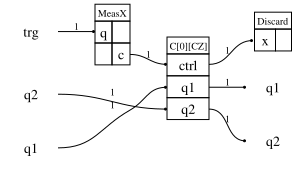

In [9]:
from qualtran import Side

from qualtran.bloqs.basic_gates.x_basis import MeasX, PlusState
from qualtran.bloqs.basic_gates.z_basis import MeasZ, ZeroState
from qualtran.bloqs.basic_gates import CZ, Hadamard, CNOT
from qualtran.bloqs.basic_gates.discard import Discard

from qualtran import CtrlSpec, Controlled, CBit

bb = BloqBuilder()
q1 = bb.add_register('q1', 1)
q2 = bb.add_register('q2', 1)
trg = bb.add_register(Register('trg', QBit(), side=Side.LEFT))

#ctrg, = bb.add_from(meas_cbloq, q=trg)
ctrg = bb.add(MeasX(), q=trg)
#trg = bb.add(Hadamard(), q=trg)
#ctrg = bb.add(MeasZ(), q=trg)

classicall_controlled_cz = Controlled(CZ(), CtrlSpec(qdtypes=(CBit(),), cvs=1))

ctrg, q1, q2 = bb.add(
    classicall_controlled_cz,
    **{classicall_controlled_cz.ctrl_reg_names[0]: ctrg,
       'q1': q1,
       'q2': q2
      }
)
bb.add(Discard(), x=ctrg)

#ccz, add_ccz = CZ().get_ctrl_system(CtrlSpec())
#add_ccz(bb, ctrl_soqs=[ctrg], in_soqs={'q1': q1, 'q2': q2})


cbloq = bb.finalize(q1=q1, q2=q2)
show_bloq(cbloq)

In [10]:
classicall_controlled_cz.tensor_contract()

array([[ 1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j],
       [ 0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j],
       [ 0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j,
         0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j,
         0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
        -1.+0.j]])

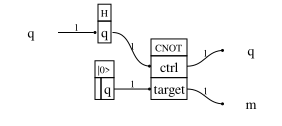

In [11]:
bb = BloqBuilder()
q = bb.add_register('q', 1)
q = bb.add(Hadamard(), q=q)

m = bb.add(ZeroState())
q, m = bb.add(CNOT(), ctrl=q, target=m)


meascbloq = bb.finalize(q=q, m=m)
show_bloq(meascbloq)

In [12]:
meascbloq.signature

Signature((Register(name='q', dtype=QBit(), _shape=(), side=<Side.THRU: 3>), Register(name='m', dtype=QBit(), _shape=(), side=<Side.RIGHT: 2>)))

In [13]:
meascbloq.tensor_contract()

array([[ 0.70710678+0.j,  0.70710678+0.j],
       [ 0.        +0.j,  0.        +0.j],
       [ 0.        +0.j,  0.        +0.j],
       [ 0.70710678+0.j, -0.70710678+0.j]])

In [14]:
#meast = meastn.contract()
#meast

In [15]:
#meast.data.transpose(1,2,0).reshape((2*2, 2))

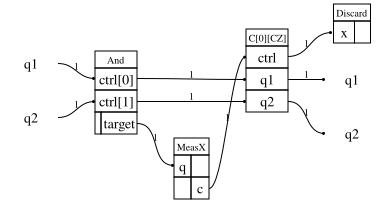

In [16]:
from qualtran.bloqs.mcmt import And

bb = BloqBuilder()
q1 = bb.add_register('q1', 1)
q2 = bb.add_register('q2', 1)
(q1, q2), trg = bb.add(And(), ctrl=[q1,q2])

q1, q2 = bb.add_from(cbloq, q1=q1, q2=q2, trg=trg)
cunc = bb.finalize(q1=q1, q2=q2)
show_bloq(cunc)

In [17]:
from qualtran.simulation.tensor._quimb import cbloq_to_superquimb
tn = cbloq_to_superquimb(cunc)

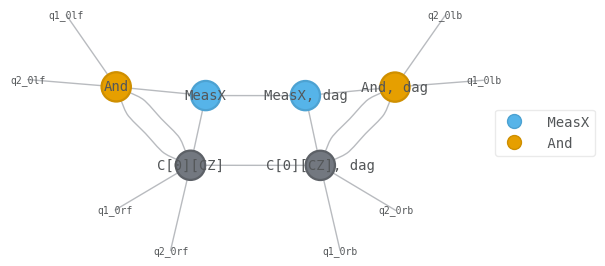

In [18]:
from qualtran import LeftDangle, RightDangle

namemap = {}
for ind in tn.outer_inds():
    cxn, j, forward = ind
    if cxn.left.binst is LeftDangle:
        soq = cxn.left
        side = 'l'
    if cxn.right.binst is RightDangle:
        soq = cxn.right
        side = 'r'

    d = 'f' if forward else 'b'
    idx = f'{soq.idx}' if soq.idx else ''
    namemap[ind] = f'{soq.reg.name}{idx}_{j}{side}{d}'
tn2 = tn.reindex(namemap)
tn2.draw(color=['MeasX', 'And'])
    

In [19]:
tn2.contract()

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2), inds=('q1_0lf', 'q2_0lf', 'q1_0lb', 'q2_0lb', 'q1_0rf', 'q2_0rf', 'q1_0rb', 'q2_0rb'), tags=oset(['And', 'dag', 'MeasX', 'C[0][CZ]']))

In [20]:
np.where(np.abs(tn2.to_dense(
    ['q1_0rf', 'q2_0rf', 'q1_0rb', 'q2_0rb'],
    ['q1_0lf', 'q2_0lf', 'q1_0lb', 'q2_0lb']
)) > 1e-8)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]))

In [21]:
import quimb.tensor as qtn
tnf, tnb = tn2.split(method='svd',
                     left_inds = ['q2_0lf', 'q1_0lf', 'q2_0rf', 'q1_0rf'],
                     absorb='both', bond_ind='j')
display(tnf)
display(tnf.data[:,:,:,:,0].reshape(4,4).round(4))

Tensor(shape=(2, 2, 2, 2, 1), inds=('q2_0lf', 'q1_0lf', 'q2_0rf', 'q1_0rf', 'j'), tags=oset(['And', 'dag', 'MeasX', 'C[0][CZ]']))

array([[-1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j, -1.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j]])

In [22]:
cbloq.call_classically(q1=1, q2=1, trg=1)

ValueError: {binst} has non-deterministic classical action. TODO: advice.

In [23]:
import numpy.random
import numpy as np

In [24]:
gen = np.random.default_rng(seed=None)

In [25]:
gen.choice(2, p=None)

1

In [26]:
meas_binst_is = [binst.i for binst in cbloq.bloq_instances if binst.bloq_is(MeasX)]
meas_binst_is

[0]

In [27]:
from qualtran.simulation.classical_sim import _PhasedClassicalSimState

def run_debug_sim(sim):
    try:
        while True:
            sim.step()
            print("\nStepped over", sim.last_binst)
            for soq, val in sim.soq_assign.items():
                print(' ', soq, '=', val)
            print("  phase =", sim.phase)
            
    except StopIteration:
        res = sim.finalize()
    return res, sim.phase

def run_debug_sim_2(sim):
    try:
        while True:
            sim.step()
            if sim.phase == 1.0:
                print('+', end='')
            elif sim.phase == -1.0:
                print('-', end='')
            else:
                print('?', end='')
            
    except StopIteration:
        res = sim.finalize()
    return res, sim.phase

#run_debug_sim(sim)
rng = np.random.default_rng()
for j in range(20):
    print(f'j: {j:2d}', end=' ')
    sim = _PhasedClassicalSimState.from_cbloq(cbloq, {'q1': 1, 'q2': 1, 'trg':1}, rng=rng)
    run_debug_sim_2(sim)
    print()

j:  0 +++++
j:  1 +++++
j:  2 +-+++
j:  3 +-+++
j:  4 +-+++
j:  5 +-+++
j:  6 +-+++
j:  7 +++++
j:  8 +-+++
j:  9 +-+++
j: 10 +++++
j: 11 +-+++
j: 12 +-+++
j: 13 +++++
j: 14 +-+++
j: 15 +++++
j: 16 +++++
j: 17 +++++
j: 18 +++++
j: 19 +++++


In [28]:
from qualtran.simulation.classical_sim import _PhasedClassicalSimState
import itertools

for q1, q2 in itertools.product(range(2), repeat=2):
    trg = int(q1==1 and q2 == 1)
    print(f'{q1=}, {q2=}, {trg=}')

    for meas_result in itertools.product(range(2), repeat=len(meas_binst_is)):
        print(f'  meas {meas_result}', end=' ')
        meas_results = {binst_i: meas_result[j] for j, binst_i in enumerate(meas_binst_is)}

        sim = _PhasedClassicalSimState.from_cbloq(cbloq, {'q1': q1, 'q2': q2, 'trg':trg}, fixed_rnd_vals=meas_results)
        #out_vals = sim.simulate()
        out_vals, phase = run_debug_sim_2(sim)
        
        assert out_vals['q1'] == q1
        assert out_vals['q2'] == q2
        assert 'trg' not in out_vals
        assert phase == 1.0
        print(' ✓')
        


q1=0, q2=0, trg=0
  meas (0,) +++++ ✓
  meas (1,) +++++ ✓
q1=0, q2=1, trg=0
  meas (0,) +++++ ✓
  meas (1,) +++++ ✓
q1=1, q2=0, trg=0
  meas (0,) +++++ ✓
  meas (1,) +++++ ✓
q1=1, q2=1, trg=1
  meas (0,) +++++ ✓
  meas (1,) +-+++ ✓


In [ ]:
%debug

In [ ]:
import quimb.tensor as qtn

In [ ]:
circ = qtn.Circuit()

## `MultiAnd`
A many-bit (multi-control) 'and' operation.

#### Parameters
 - `cvs`: A tuple of control variable settings. Each entry specifies whether that control line is a "positive" control (`cv[i]=1`) or a "negative" control `0`. If a HasLength object is passed, assumes the control values to be all 1's.  

#### Registers
 - `ctrl`: An n-bit control register.
 - `junk [right]`: An `n-2` bit junk register to be cleaned up by the inverse operation.
 - `target [right]`: The output bit.


In [ ]:
from qualtran.bloqs.mcmt import MultiAnd

### Example Instances

In [ ]:
multi_and = MultiAnd(cvs=(1, 0, 1, 0, 1, 0))

#### Graphical Signature

In [ ]:
from qualtran.drawing import show_bloqs
show_bloqs([multi_and],
           ['`multi_and`'])

### Call Graph

In [ ]:
from qualtran.resource_counting.generalizers import ignore_split_join
multi_and_g, multi_and_sigma = multi_and.call_graph(max_depth=1, generalizer=ignore_split_join)
show_call_graph(multi_and_g)
show_counts_sigma(multi_and_sigma)

## Additional Demos

### Testing with states and effects

We can use `ZeroState` and its friends to test the truth table on this classical logic.

In [ ]:
from qualtran.bloqs.basic_gates import OneEffect, OneState, ZeroEffect, ZeroState

state = [ZeroState(), OneState()]
eff = [ZeroEffect(), OneEffect()]

# Experiment with changing the following:
cvs = (1, 1, 1)
ctrl_string = (1, 1, 1)


bb = BloqBuilder()
ctrl_qs = [bb.add(state[c]) for c in ctrl_string]
ctrl_qs, junk, res = bb.add_from(MultiAnd(cvs), ctrl=ctrl_qs)
for c, q in zip(ctrl_string, ctrl_qs):
    bb.add(eff[c], q=q)

cbloq = bb.finalize(junk=junk, res=res)
show_bloq(cbloq)

In [ ]:
# Our tensor network now just has the result index and a junk index.
# We use `np.where` to find non-zero entries into this.
# In fact -- the second index corresponding to `res` is the bit output
vec = cbloq.tensor_contract()
junk_i, res_i = np.where(vec.reshape((2, 2)))
res_i

In [ ]:
# The truthiness of the non-zero res index should match the desired logical function.
should_be = np.all(ctrl_string == cvs)
should_be

### Classical Simulation

The `And` gate is classical logic, so we can simulate it on discrete bitstrings.

In [ ]:
ctrl, out = And().call_classically(ctrl=np.array([1, 1]))
out

In [ ]:
ctrl = np.array([1,1,1,1])
ctrl, junk, out = MultiAnd((1,1,1,1)).call_classically(ctrl=ctrl)
out

In [ ]:
from qualtran.drawing import ClassicalSimGraphDrawer

ClassicalSimGraphDrawer(
    MultiAnd((1,1,1,1)).decompose_bloq(), 
    vals=dict(ctrl=[1,1,0,1])
).get_svg()